# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter







### Import human data

In [ ]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_short*/data/*.json"))
len(human_fnames)

232

## Process Human Results

In [3]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
total_trials = 192
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72026 (char 72025)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6533ba7daced485bbd50324c.json
Unterminated string starting at: line 1 column 84036 (char 84035)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6393f158851fb438d2ceb5d7.json
Unterminated string starting at: line 1 column 300481 (char 300480)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_64275d22f204d1161ad23e64.json
Unterminated string starting at: line 1 column 300457 (char 300456)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_631ffc3584141f143567f021.json
Unterminated string starting at: line 1 column 168069 (char 168068)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5978f6f009bdcf000153f43d.json
Expecting ',' delimiter: line 1 column 24016 (char 24015)
/mindh

Unterminated string starting at: line 1 column 108139 (char 108138)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_654110840e6a9717486c8aa2.json
Unterminated string starting at: line 1 column 96008 (char 96007)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5f4bd540586c807baf3f17d3.json
Unterminated string starting at: line 1 column 11986 (char 11985)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_59922fa30675b100014daed4.json
Unterminated string starting at: line 1 column 108058 (char 108057)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5d5167d1374c5d0001b56d8b.json
Unterminated string starting at: line 1 column 252256 (char 252255)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5d01b9d4c9281200151c7c6b.json
Expecting ',' delimiter: line 1 column 108074 (char 108073)
/min

/tmp/ipykernel_1087308/2465272808.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['condition'] = trial_results['condition'].replace(condition_map)


In [ ]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
# catch_trial_particiapnt_performance

In [5]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  116
N good participants  95



## Add re-scored performance based on entries included in excerpt transcripts  

In [6]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
# analysis_df.groupby('id_subject').condition.count()
# manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_single_distractor_ground_truth_manifest.pdpkl")
manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_all_condition_ground_truth_manifest.pdpkl")

manifests['cond_folder'] = manifests['base_str'].apply(lambda x: x.split('/')[1])

analysis_df = pd.merge(analysis_df,
                        manifests[['base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                                    left_on='stimulus', right_on='base_str', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.correct_response.values
distractor_words = analysis_df.distractor_word.values
target_transcripts = analysis_df.target_transcript.values
distractor_transcripts = analysis_df.distractor_transcript.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not (isinstance(target_transcript, float)) else np.nan
                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not (isinstance(distractor_transcript, float)) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df = analysis_df[~analysis_df.condition.isin(['catch_trial'])]


analysis_df.loc[analysis_df.condition == '1-talker', 'sex_cond'] =  analysis_df[analysis_df.condition == '1-talker'].apply(lambda x: "Same sex" if x.target_gender == x.distractor_gender else "Different sex", axis=1)
# fold sex cond into condition as separate rows 
analysis_df = analysis_df.melt(id_vars=['id_subject', 'condition', 'snr', 'sex_cond'], value_vars=['adjusted_accuracy', 'adjusted_confusions'], var_name='measure', value_name='score')
analysis_df = analysis_df.melt(id_vars=['id_subject', 'snr', 'measure', 'score'], value_vars=['condition', 'sex_cond'], var_name='origin', value_name='background_condition')
analysis_df = analysis_df[~analysis_df.background_condition.isna()]
analysis_df = analysis_df[~((analysis_df.measure == 'adjusted_confusions') & (~analysis_df.background_condition.isin(['1-talker', 'Same sex', "Different sex"])))]


In [7]:
analysis_df

,id_subject,snr,measure,score,origin,background_condition
0,66775344eabb4cc1cbc0120e,-6,adjusted_accuracy,0.0,condition,stationary
1,66775344eabb4cc1cbc0120e,0,adjusted_accuracy,1.0,condition,1-talker
2,66775344eabb4cc1cbc0120e,-3,adjusted_accuracy,1.0,condition,4-talker
3,66775344eabb4cc1cbc0120e,3,adjusted_accuracy,1.0,condition,babble
4,66775344eabb4cc1cbc0120e,-3,adjusted_accuracy,1.0,condition,modulated
...,...,...,...,...,...,...
68371,64189ea918b2fee8a9504b32,-6,adjusted_confusions,1.0,sex_cond,Different sex
68372,64189ea918b2fee8a9504b32,-9,adjusted_confusions,0.0,sex_cond,Same sex
68377,64189ea918b2fee8a9504b32,-6,adjusted_confusions,0.0,sex_cond,Same sex
68381,64189ea918b2fee8a9504b32,-9,adjusted_confusions,0.0,sex_cond,Different sex


In [8]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "background_condition", "measure"])
                     .agg({'score':['mean', 'sem', 'count']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]
# part_summary_df = part_summary_df[~((part_summary_df.measure == 'adjusted_confusions_mean') & (part_summary_df.background_condition != '1-talker'))]


/tmp/ipykernel_1087308/3327551247.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)


## Run Power analysis 

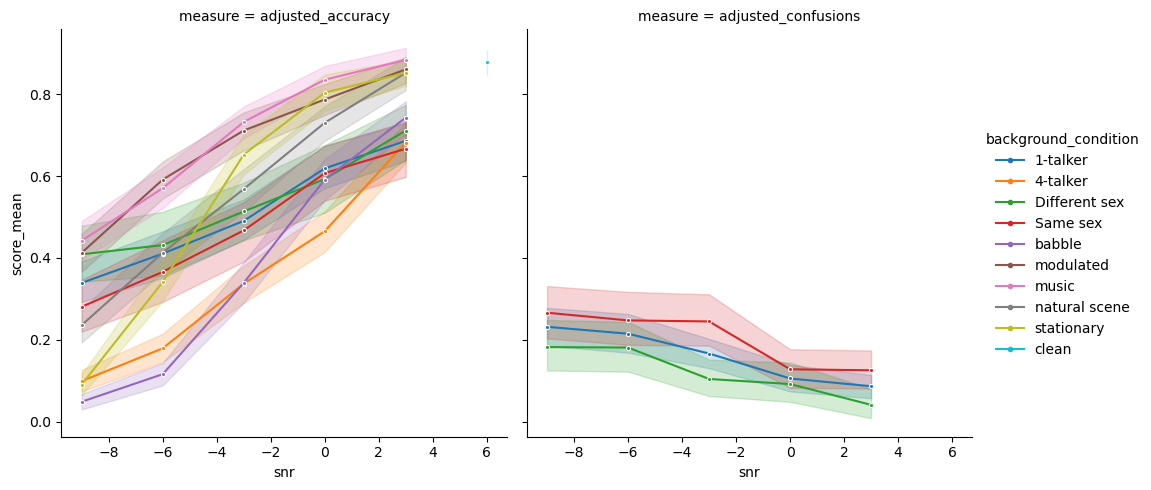

In [9]:
sns.relplot(data=part_summary_df, x='snr', y='score_mean', hue='background_condition', col='measure', kind='line', marker='.')

In [23]:

from scipy import stats
from src.util_analysis import split_half_reliability
from tqdm.auto import tqdm

np.random.seed(42)

n_splits = 100

conditiosn_to_include = ["1-talker", "babble", "4-talker"]
metric_str = "adjusted_accuracy"
for_power_analysis_df = part_summary_df[(part_summary_df.snr == 0) 
        & (part_summary_df.background_condition.isin(conditiosn_to_include))
        & (part_summary_df.measure == metric_str)]

participant_ids = for_power_analysis_df.id_subject.unique()
max_n_participants = len(participant_ids) // 2 
# get range from 10 to max_n_participants in even steps 
participant_range = np.arange(2, max_n_participants, 2)

n_split_data = np.zeros((len(participant_range), n_splits))

groupby_condition = ['snr', 'background_condition', 'measure']
measure_string = "score_mean"
full_condition_index = pd.MultiIndex.from_frame(
    for_power_analysis_df[groupby_condition].drop_duplicates().sort_values(groupby_condition)
)

for ix, n_participants in tqdm(enumerate(participant_range), total=len(participant_range)):
    for split_ix in range(n_splits):
        split_participants = np.random.choice(participant_ids, size=n_participants*2, replace=False)
        split_a_participants = split_participants[:n_participants]
        split_b_participants = split_participants[n_participants:]

        split_a_data = for_power_analysis_df[for_power_analysis_df.id_subject.isin(split_a_participants)].copy()
        split_b_data = for_power_analysis_df[for_power_analysis_df.id_subject.isin(split_b_participants)].copy()

        split_a_series = (
            split_a_data.groupby(groupby_condition)[measure_string]
            .mean()
            .reindex(full_condition_index)
        )
        split_b_series = (
            split_b_data.groupby(groupby_condition)[measure_string]
            .mean()
            .reindex(full_condition_index)
        )

        valid_mask = split_a_series.notna() & split_b_series.notna()
        if valid_mask.sum() < 2:
            n_split_data[ix, split_ix] = np.nan
            continue

        r, p = stats.pearsonr(split_a_series[valid_mask], split_b_series[valid_mask])
        n_split_data[ix, split_ix] = r
        


  0%|          | 0/23 [00:00<?, ?it/s]

/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4847: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWar

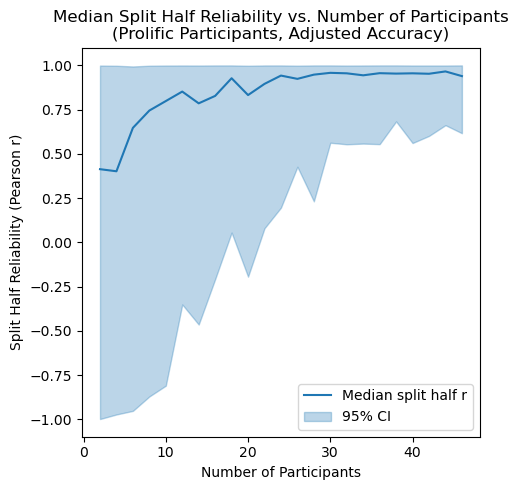

In [24]:
## Plot results, where we show median split half reliability with confidence intervals for each number of participants 
# Calculate median and confidence intervals
median_r = np.nanmedian(n_split_data, axis=1)
lower_ci = np.nanpercentile(n_split_data, 2.5, axis=1)
upper_ci = np.nanpercentile(n_split_data, 97.5, axis=1)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(participant_range, median_r, label='Median split half r', color='C0')
ax.fill_between(participant_range, lower_ci, upper_ci, color='C0', alpha=0.3, label='95% CI')
ax.set_xlabel('Number of Participants')
ax.set_ylabel('Split Half Reliability (Pearson r)')
ax.set_title('Median Split Half Reliability vs. Number of Participants\n(Prolific Participants, Adjusted Accuracy)')
# ax.set_ylim([0,1])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()